## Chapter 7: XGBoost for Time Series Forecasting
1. Import Libraries

In [3]:
# Import necessary libraries for numerical operations, data handling, visualization, and modeling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

## 2. Create Synthetic Time Series Data

In [4]:
# Create a synthetic time series dataset with trend, seasonality, and noise

np.random.seed(42)
n = 300

time = np.arange(n)

data = 10 + 0.05 * time + np.sin(time * 0.2) + np.random.normal(0, 0.5, n)

df = pd.DataFrame({"value": data})

# We generate a realistic time series:

# Trend: linear growth (0.05 * time)
# Seasonality → sine wave pattern
# Noise → randomness (real-world uncertainty)

# This simulates real-world data like sales or stock prices.

## 3. Feature Engineering (Lag + Rolling Features)

In [5]:
# Create lag features (past values)

df["lag1"] = df["value"].shift(1)
df["lag2"] = df["value"].shift(2)
df["lag3"] = df["value"].shift(3)

# Create rolling statistics (window-based features)

df["rolling_mean_3"] = df["value"].rolling(window=3).mean()
df["rolling_std_3"] = df["value"].rolling(window=3).std()

# Remove missing values created by shifting

df = df.dropna()

## 4. Define Features (X) and Target (y)

In [6]:
# Split dataset into input features and target variable

X = df.drop("value", axis=1)
y = df["value"]

## 5. Train-Test Split (Time-Aware Split)

In [7]:
# Split data while preserving time order (NO shuffling)

train_size = int(len(df) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

## 6. Train XGBoost Model

In [8]:
# Initialize XGBoost Regressor model

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    objective="reg:squarederror"
)

# Train the model

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## 7. Make Predictions

In [9]:
# Predict future values using trained model

y_pred = model.predict(X_test)

## 8. Model Evaluation (RMSE)

In [10]:
# Calculate Root Mean Squared Error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 2.5922134967831467


## 9. Visualization (Actual vs Predicted)

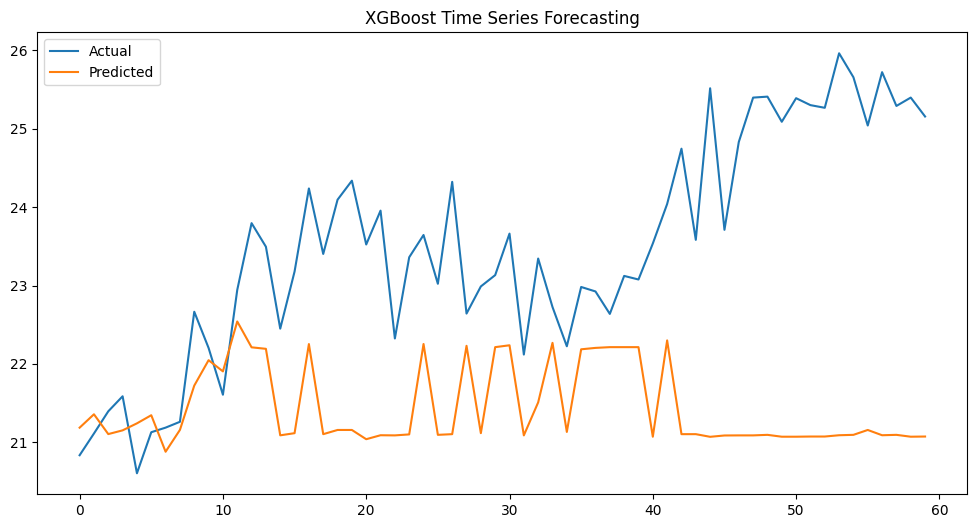

In [11]:
# Plot actual vs predicted values

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("XGBoost Time Series Forecasting")
plt.legend()
plt.show()